# Improved 1D CNN for Heart Rate Interval Segmentation

**Master's Thesis Implementation**

This notebook implements an improved 1D CNN with residual connections and multi-scale kernels for detecting workout interval boundaries from heart rate data.

Run all cells from top to bottom.

## 1. Imports

In [17]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")
print("Imports complete")

TensorFlow version: 2.20.0
Imports complete


## 2. Configuration

In [18]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60
    
    # Post-processing
    peak_distance: int = 20
    peak_prominence: float = 0.15
    smooth_sigma: float = 3.0
    
    # CNN specific
    segment_length: int = 300      # 5 minutes at 1Hz
    segment_overlap: int = 150     # 50% overlap
    cnn_epochs: int = 50
    cnn_batch_size: int = 32
    cnn_patience: int = 15

CONFIG = Config()
print(f"Configuration set")

Configuration set


## 3. Data Configuration

In [19]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },
    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },
    "AthletesSpecialRowing": {
        "sport": "rowing",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
        "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## 4. Feature Engineering

In [20]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:

    features = pd.DataFrame(index=df.index)
    hr = df['heart_rate'].values

    # Session-level statistics
    session_mean = hr.mean()
    session_std = hr.std()
    session_max = hr.max()
    session_min = hr.min()
    session_range = session_max - session_min
    session_p25 = np.percentile(hr, 25)
    session_p75 = np.percentile(hr, 75)
    session_iqr = session_p75 - session_p25

    # Interval density features
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()
        expected_interval_length = session_duration / n_expected_intervals
        intervals_per_minute = n_expected_intervals / (session_duration / 60)
        features['intervals_per_minute'] = intervals_per_minute
        features['expected_interval_length'] = expected_interval_length

    # Smoothed HR
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # Normalized HR
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)

    # Temporal features
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)

    # Rolling statistics
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()

    # Relative features
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']
    features['hr_vs_session_p75'] = hr - session_p75

    # Past to future change
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - df['heart_rate'].shift(60)
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)

    # Session-normalized intensity
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)

    # Derivatives
    features['hr_diff_5s'] = df['heart_rate'].diff(5)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)

    # Change from lag
    features['hr_change_from_lag60'] = hr - df['heart_rate'].shift(60)
    features['hr_change_from_lag30'] = hr - df['heart_rate'].shift(30)
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)

    # Trend indicators
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)

    # High density session flag
    if n_expected_intervals is not None:
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)

    # More session comparison features
    features['hr_vs_session_mean'] = hr - session_mean
    features['hr_vs_session_p25'] = hr - session_p25
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)

    # Short window max
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()

    # Zone indicators
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)
    features['in_low_zone'] = (hr < session_p25).astype(int)

    # Lagged features
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)

    # Z-score
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)

    # Percentage change
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # Session constants
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_mean'] = session_mean

    # Clean up
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

## 5. Post-Processing

In [21]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    if n_expected_intervals >= 50:
        peak_distance = 3
    elif n_expected_intervals >= 35:
        peak_distance = 5
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance

    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 6. Evaluation

In [22]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Bipartite greedy matching: closest pairs first, no double matching
    pairs = []
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                pairs.append((abs(time_diff), pred_idx, true_idx))

    pairs.sort()  # closest pairs first
    used_pred = set()
    used_true = set()
    matched_pairs = []

    for dist, pred_idx, true_idx in pairs:
        if pred_idx not in used_pred and true_idx not in used_true:
            matched_pairs.append((pred_idx, true_idx, dist))
            used_pred.add(pred_idx)
            used_true.add(true_idx)

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)
    n_matched = len(matched_pairs)

    precision = n_matched / n_pred if n_pred > 0 else 0
    recall = n_matched / n_true if n_true > 0 else 0

    beta = np.sqrt(2)
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # MAE: all predictions to nearest ground truth (unbounded)
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())
    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 7. Data Loading

In [23]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"  {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"  Error loading {filename}: {e}")
    
    return session_data

print("Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\nLoaded {len(hr_session_data)} sessions total")

Loading session data...
  Athlete12 - 13582048984_W_Up
  Athlete12 - 14125110656_Vallah_isch_balla
  Athlete12 - 13583093636_Afterburner_
  Athlete12 - 10809067165_3007_row
  Athlete12 - 10674304801_Btchen_fahren_in_Etappen_3
  Athlete12 - 11838948742_3006_row
  Athlete12 - 10652950510_Btchen_fahren
  Athlete12 - 14156450361_On_a_mission
  Athlete12 - 11994450315_Airobics
  Athlete12 - 14135321532_Pimp_my_ride
  Athlete12 - 12951604563_DienstSport
  Athlete12 - 13280559542_Warm_up_rowing
  Athlete12 - 12806981726_Row_Stretch__Stabi
  Athlete12 - 14374019349_Uff
  Athlete12 - 10536403349_5006_row
  Athlete12 - 14038989670__Hyperthermie_
  Athlete12 - 13672121049_Base_Miles
  Athlete12 - 13609970768_Uffwrme
  Athlete12 - 13918354210_W_Upen
  Athlete12 - 14077735636_Base
  Athlete12 - 13971240869_A_ella_le_gusta
  Athlete12 - 13662882990_Heldentod
  Athlete12 - 13039020832_Analytiker
  Athlete12 - 14396237986_4659_row
  Athlete12 - 11846980624_Platt_
  Athlete12 - 11987690514_Besser_als_N

## 8. Prepare Train/Test Data

In [24]:
print("Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}

found_test_sessions = set()

for (athlete, session), df in hr_session_data.items():
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()

    features_df = create_hr_features(df, CONFIG, n_intervals)
    X = features_df.values

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"  Skipping {session} - invalid values")
        continue

    sport = athletes[athlete]['sport']

    session_info = {
        'athlete': athlete,
        'session': session,
        'sport': sport,
        'X': X,
        'y': y,
        'n_intervals': n_intervals,
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df
    }

    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

missing_test_sessions = set(test_sessions) - found_test_sessions
if missing_test_sessions:
    print("\nWARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        print(f"   {athlete}: {session}")
else:
    print("\nAll test sessions found successfully")

X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

# Also transform train session arrays for segment creation
offset = 0
for session in train_sessions:
    n = len(session['y'])
    session['X'] = X_train[offset:offset+n]
    offset += n

print(f"\nDataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"     - Biking: {train_sport_count['biking']}")
print(f"     - Rowing: {train_sport_count['rowing']}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"     - Biking: {test_sport_count['biking']}")
print(f"     - Rowing: {test_sport_count['rowing']}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")

Preparing train/test datasets...

   Athlete12: 12989160676_Wohnzimmerromantik

Dataset prepared:
   Training sessions: 75
     - Biking: 24
     - Rowing: 51
   Test sessions: 18
     - Biking: 6
     - Rowing: 12
   Training samples: 278,990 (1428 positive)
   Features: 39


## 9. Prepare CNN Segments

In [25]:
def prepare_cnn_segments(sessions, seg_len, overlap):
    """Create overlapping segments for CNN training."""
    all_X, all_y = [], []
    stride = seg_len - overlap
    for s in sessions:
        X, y = s['X'], s['y']
        for i in range((len(X) - seg_len) // stride + 1):
            start = i * stride
            end = start + seg_len
            if end <= len(X):
                all_X.append(X[start:end])
                all_y.append(y[start:end])
    return np.array(all_X), np.array(all_y)

# Reset seeds for reproducible train/val split and training
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Session-level validation split (~15% of training sessions)
n_val = max(1, int(len(train_sessions) * 0.15))
random.shuffle(train_sessions)
val_sessions = train_sessions[:n_val]
actual_train_sessions = train_sessions[n_val:]

X_train_cnn, y_train_cnn = prepare_cnn_segments(actual_train_sessions, CONFIG.segment_length, CONFIG.segment_overlap)
X_val_cnn, y_val_cnn = prepare_cnn_segments(val_sessions, CONFIG.segment_length, CONFIG.segment_overlap)

# Expand labels to (batch, time, 1) for Conv1D output
y_train_cnn = y_train_cnn[..., np.newaxis]
y_val_cnn = y_val_cnn[..., np.newaxis]

n_features = X_train_cnn.shape[2]
print(f"Train segments: {X_train_cnn.shape}")
print(f"Val segments: {X_val_cnn.shape}")
print(f"Train positive: {y_train_cnn.sum():.0f}/{y_train_cnn.size} ({y_train_cnn.sum()/y_train_cnn.size*100:.3f}%)")
print(f"Val sessions: {n_val}, Train sessions: {len(actual_train_sessions)}")

Train segments: (1544, 300, 39)
Val segments: (216, 300, 39)
Train positive: 2451/463200 (0.529%)
Val sessions: 11, Train sessions: 64


## 10. Build Improved CNN Model

In [26]:
def residual_block(x, filters, kernel_size, dropout_rate=0.2):
    """Residual block with two Conv1D layers."""
    shortcut = x
    # Project shortcut if channel mismatch
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    out = layers.Conv1D(filters, kernel_size, padding='same')(x)
    out = layers.BatchNormalization()(out)
    out = layers.ReLU()(out)
    out = layers.Dropout(dropout_rate)(out)

    out = layers.Conv1D(filters, kernel_size, padding='same')(out)
    out = layers.BatchNormalization()(out)

    out = layers.Add()([out, shortcut])
    out = layers.ReLU()(out)
    return out


def build_improved_cnn(input_shape):
    """Build improved 1D CNN with residual connections and multi-scale kernels."""
    inputs = layers.Input(shape=input_shape)

    # Initial projection
    x = layers.Conv1D(64, 1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Multi-scale residual blocks
    x = residual_block(x, 64, kernel_size=3, dropout_rate=0.2)    # Local patterns
    x = residual_block(x, 64, kernel_size=7, dropout_rate=0.2)    # Short-term trends
    x = residual_block(x, 128, kernel_size=15, dropout_rate=0.3)  # Medium-term patterns
    x = residual_block(x, 128, kernel_size=31, dropout_rate=0.3)  # Long-term transitions

    # Output head
    x = layers.Conv1D(64, 1, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Conv1D(1, 1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model


model = build_improved_cnn((CONFIG.segment_length, n_features))
model.summary()

# Weighted loss for class imbalance
pos_weight = (y_train_cnn.size - y_train_cnn.sum()) / max(y_train_cnn.sum(), 1)

def weighted_bce(y_true, y_pred):
    bce = keras.backend.binary_crossentropy(y_true, y_pred)
    weight_map = y_true * (pos_weight - 1) + 1
    return keras.backend.mean(bce * weight_map)

model.compile(optimizer=keras.optimizers.Adam(0.001), loss=weighted_bce, metrics=['accuracy'])
print(f"Positive weight: {pos_weight:.1f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 39)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 300, 64)   │      2,560 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_9 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 300, 64)   │     12,352 │ re_lu_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_13[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_10 (ReLU)     │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 300, 64)   │          0 │ re_lu_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 300, 64)   │     12,352 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 300, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_11 (ReLU)     │ (None, 300, 64)   │          0 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 300, 64)   │     28,736 │ re_lu_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_15[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 300, 64)   │          0 │ re_lu_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 300, 64)   │     28,736 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 300, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 300, 64)   │          0 │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 300, 128)  │    123,008 │ re_lu_13[0][0]  

 Total params: 1,489,665 (5.68 MB)

 Trainable params: 1,488,001 (5.68 MB)

 Non-trainable params: 1,664 (6.50 KB)

Positive weight: 188.0


## 11. Train Model

In [ ]:
print("Training improved CNN...")
history = model.fit(
    X_train_cnn, y_train_cnn,
    epochs=CONFIG.cnn_epochs,
    batch_size=CONFIG.cnn_batch_size,
    validation_data=(X_val_cnn, y_val_cnn),
    callbacks=[
        EarlyStopping('val_loss', patience=CONFIG.cnn_patience, restore_best_weights=True),
        ReduceLROnPlateau('val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"Trained for {len(history.history['loss'])} epochs")

Training improved CNN...
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7546 - loss: 0.9407 - val_accuracy: 0.7132 - val_loss: 1.0010 - learning_rate: 0.0010
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 872ms/step - accuracy: 0.8122 - loss: 0.7087 - val_accuracy: 0.8715 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 746ms/step - accuracy: 0.8232 - loss: 0.6330 - val_accuracy: 0.9129 - val_loss: 0.7815 - learning_rate: 0.0010
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 860ms/step - accuracy: 0.8304 - loss: 0.5915 - val_accuracy: 0.8762 - val_loss: 0.5878 - learning_rate: 0.0010
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 829ms/step - accuracy: 0.8352 - loss: 0.5709 - val_accuracy: 0.8624 - val_loss: 0.6410 - learning_rate: 0.0010
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 46s 934ms/step - accuracy: 0.8447 - loss: 0.5475 - val_accuracy: 0.8555 - val_loss: 0.6445 - learning_rate: 0.0010
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 37s 756ms/step - accur

## 12. Evaluate on Test Sessions

In [12]:
def predict_session_cnn(model, session, seg_len, overlap):
    """Predict on a full session by stitching overlapping segments."""
    X = session['X']
    pred_sum = np.zeros(len(X))
    pred_cnt = np.zeros(len(X))
    stride = seg_len - overlap

    for i in range((len(X) - seg_len) // stride + 1):
        start = i * stride
        end = start + seg_len
        if end <= len(X):
            segment = X[start:end].reshape(1, seg_len, -1)
            pred = model.predict(segment, verbose=0)[0, :, 0]
            pred_sum[start:end] += pred
            pred_cnt[start:end] += 1

    # Handle tail end that doesn't fit a full segment
    if pred_cnt[-1] == 0 and len(X) >= seg_len:
        start = len(X) - seg_len
        segment = X[start:].reshape(1, seg_len, -1)
        pred = model.predict(segment, verbose=0)[0, :, 0]
        pred_sum[start:] += pred
        pred_cnt[start:] += 1

    return np.divide(pred_sum, pred_cnt, where=pred_cnt > 0)


print("Evaluating on test sessions...\n")

test_results = []
for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    y_pred_proba = predict_session_cnn(model, session_info, CONFIG.segment_length, CONFIG.segment_overlap)
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)

    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_pred_proba'] = y_pred_proba
    metrics['df'] = session_info['df']
    test_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall:    {avg_recall:.3f}")
print(f"  Avg Error: {avg_error:.1f} seconds")
print("="*70)

Evaluating on test sessions...

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.727 | P: 0.727 | R: 0.727 | Error: 22.5s
   Intervals: 11/11

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.700 | P: 0.700 | R: 0.700 | Error: 26.9s
   Intervals: 10/10

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 2.0s
   Intervals: 3/3

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 15.5s
   Intervals: 11/11

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.778 | P: 0.778 | R: 0.778 | Error: 13.3s
   Intervals: 9/9

Athlete12    | 14089880174_Zn_IKEA           
   F_beta(2:1): 0.625 | P: 0.625 | R: 0.625 | Error: 64.1s
   Intervals: 8/8

Athlete12    | 11783093951_4x2000_sub8       
   F_beta(2:1): 0.556 | P: 0.556 | R: 0.556 | Error: 45.7s
   Intervals: 9/9

Athlete12    | 13983533934_Technik__30er     
   F_beta(2:1): 0.636 | P: 0.636 | R: 0.636 | Err

## 13. Visualize All Test Sessions

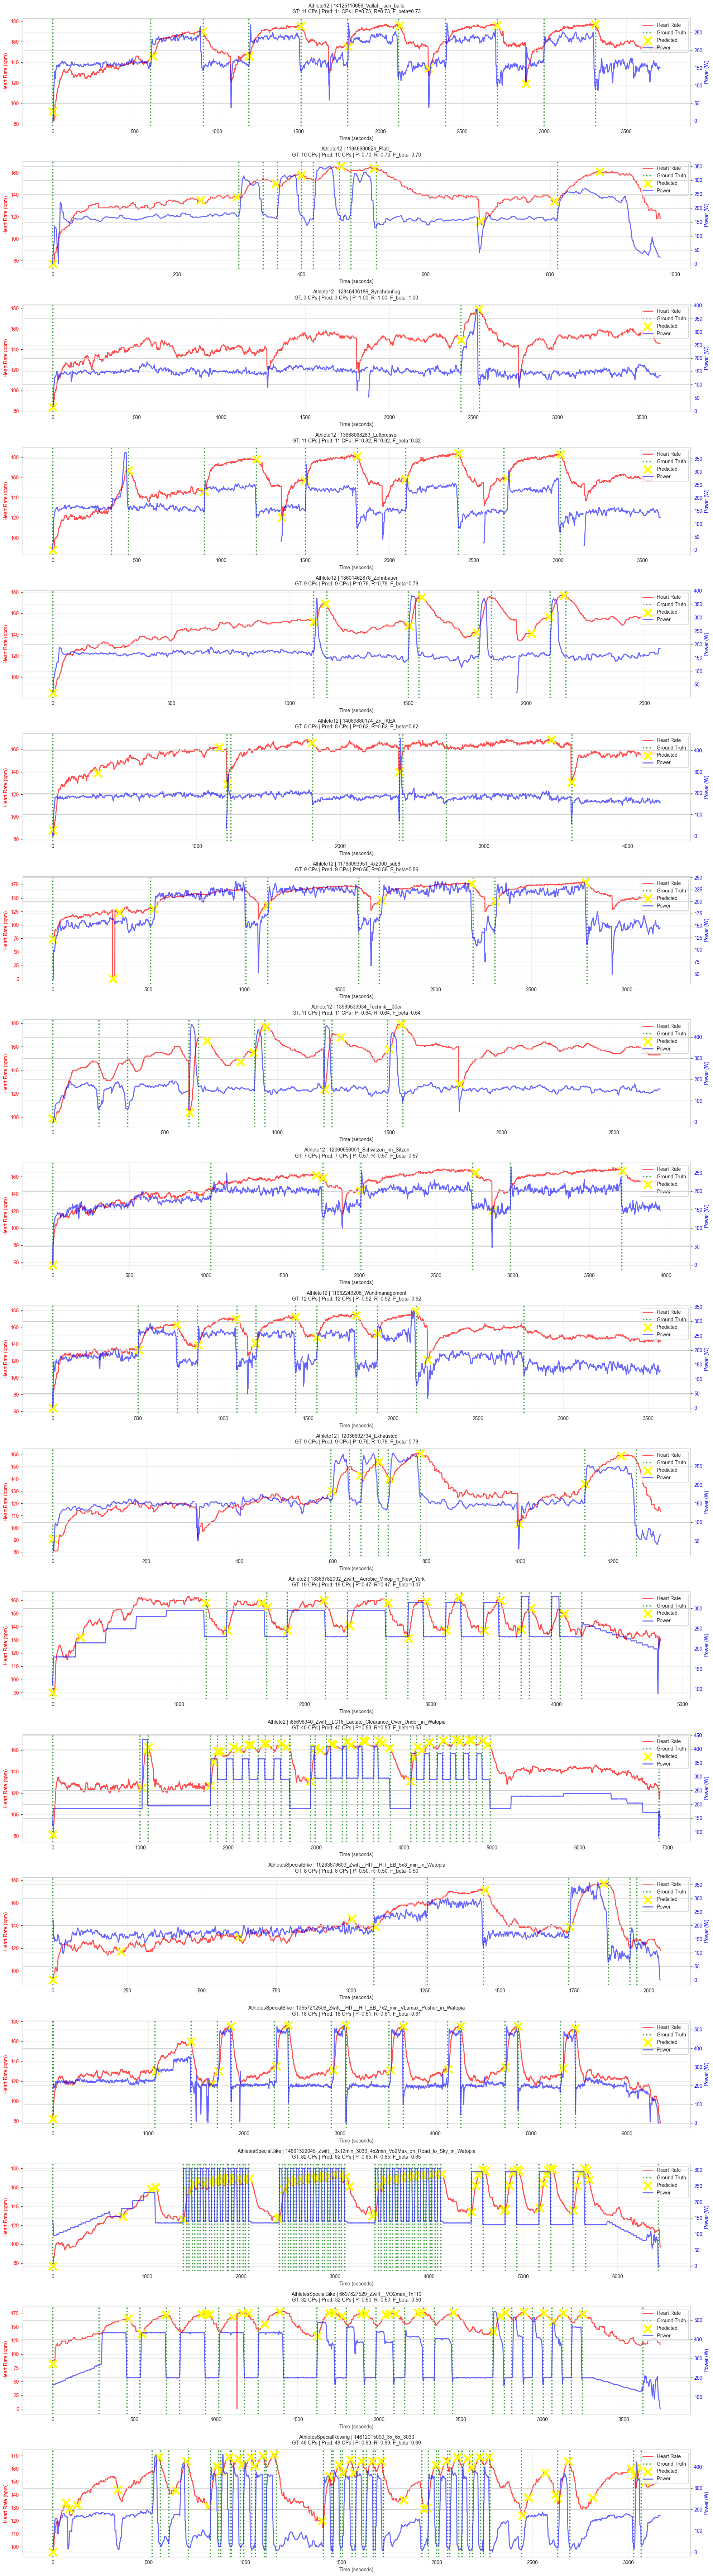

In [13]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics

Created df_results with 18 test sessions
  rowing: 12 sessions
  biking: 6 sessions


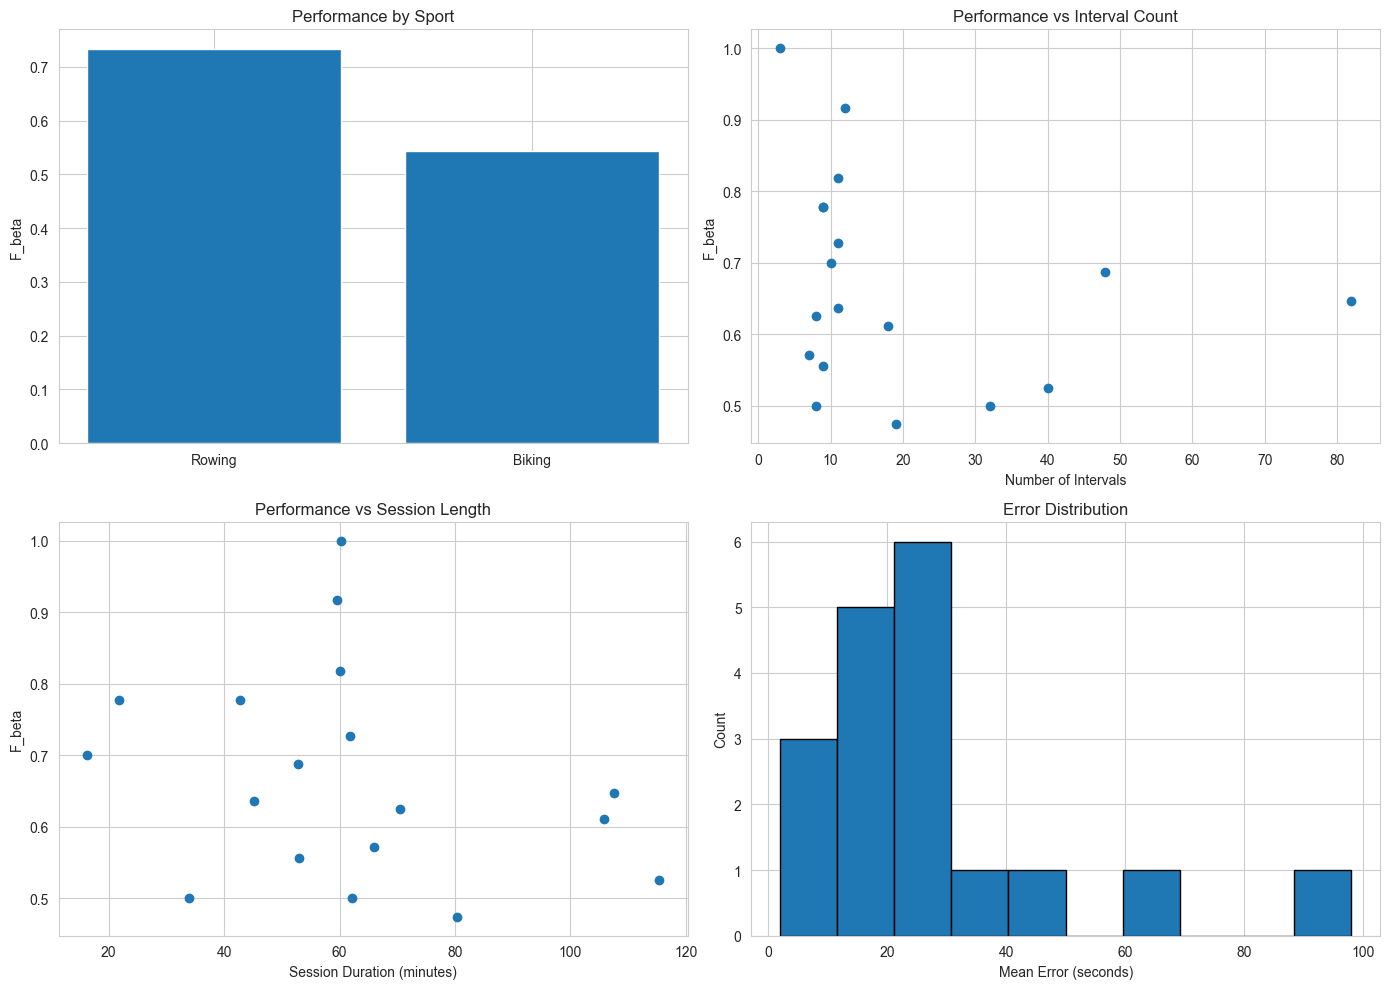

In [14]:
# Create mapping from athlete name to sport
athlete_sport_mapping = {
    athlete_name: athlete_data['sport']
    for athlete_name, athlete_data in athletes.items()
}

df_results = pd.DataFrame([
    {
        'athlete': r['athlete'],
        'session': r['session'],
        'n_intervals': r['n_true'],
        'n_pred': r['n_pred'],
        'f_beta': r['f_beta'],
        'precision': r['precision'],
        'recall': r['recall'],
        'mean_error_sec': r['mean_error_sec'],
        'duration_sec': len(r['y_true']),
        'duration_min': len(r['y_true']) / 60,
        'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
    }
    for r in test_results
])

print(f"Created df_results with {len(df_results)} test sessions")
for sport, count in df_results['sport'].value_counts().items():
    print(f"  {sport}: {count} sessions")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(['Rowing', 'Biking'],
               [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
                df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0, 0].set_ylabel('F_beta')
axes[0, 0].set_title('Performance by Sport')

axes[0, 1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0, 1].set_xlabel('Number of Intervals')
axes[0, 1].set_ylabel('F_beta')
axes[0, 1].set_title('Performance vs Interval Count')

axes[1, 0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1, 0].set_xlabel('Session Duration (minutes)')
axes[1, 0].set_ylabel('F_beta')
axes[1, 0].set_title('Performance vs Session Length')

axes[1, 1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1, 1].set_xlabel('Mean Error (seconds)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Error Distribution')

plt.tight_layout()
plt.show()

## 15. Save Results

In [15]:
import pickle

cnn_results = {
    'model_name': 'CNN_Improved',
    'results': test_results,
}

with open('results/cnn_improved_results.pkl', 'wb') as f:
    pickle.dump(cnn_results, f)

print(f"Saved {len(test_results)} CNN Improved results")

Saved 18 CNN Improved results
